In [39]:
from tambora.dynamics.integration import _integrate
from galpy.util.coords import cyl_to_rect, cyl_to_rect_vec
from tambora.util import _galpy_pot_to_acc_fn, _galpy_pot_to_pot_fn
from tambora.simulation import Sim
from galpy.potential import NFWPotential
from galpy.orbit import Orbit
import astropy.units as u
import numpy as np


t_end = 80 * u.Myr # INCREASE TO 100 Myr FOR REAL TESTS
dt = 1/200*u.Myr
ts = np.arange(0, t_end.value + dt.value, dt.value) * u.Myr
pot = NFWPotential(amp=1e13*u.Msun, a=20*u.kpc)
R, vR, vT, z, vz, phi = 8., 0.1, 220.0, 0., 0.5, 0.
pot.turn_physical_on()
pos = np.array([cyl_to_rect(R, phi, z)])
vel = np.array([(cyl_to_rect_vec(vR, vT, vz, phi) * u.km/u.s).to(u.kpc/u.Myr).value])
acc_fn = _galpy_pot_to_acc_fn(pot)
pos_out, vel_out, ts_out = _integrate(pos, vel, np.array([1.]), False, None, [acc_fn], 
                                      t_end.value, dt.value, dt.value, eps=0.0,
                                      return_self_potential=False, return_self_acceleration=False)

pot_fn = _galpy_pot_to_pot_fn(pot)
nsnaps, npart = vel_out.shape[:2]
KE = 0.5 * np.sum(vel_out**2, axis=-1)  # (nsnaps, N)
PE = pot_fn(pos_out.reshape(-1, 3), t=0).reshape(nsnaps, npart)  # flatten → eval → reshape
E_out = ((KE + PE).squeeze()* u.kpc**2/u.Myr**2).to(u.km**2/u.s**2).value
Lz_out = (pos_out[...,0]*vel_out[...,1] - pos_out[...,1]*vel_out[...,0]).squeeze()


KeyboardInterrupt: 

In [11]:
o_galpy = Orbit([R*u.kpc, vR*u.km/u.s, vT*u.km/u.s, z*u.kpc, vz*u.km/u.s, phi*u.rad])
o_galpy.integrate(ts, pot, method='leapfrog_c', dt=dt)
o_galpy.turn_physical_on()

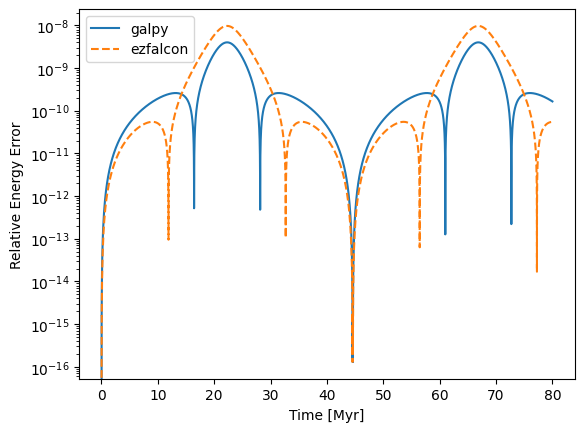

In [12]:
import matplotlib.pyplot as plt
plt.plot(ts, np.abs((o_galpy.E(ts) - o_galpy.E(ts)[0]) / o_galpy.E(ts)[0]), label='galpy', ls='-')
plt.plot(ts, np.abs((E_out - E_out[0]) / E_out[0]), label='tambora', ls='--')
plt.yscale('log')
plt.xlabel('Time [Myr]')
plt.ylabel('Relative Energy Error')
plt.legend()